# Grover's Search Algorithm

You have a list of a million items and you need to find one specific entry. 
No sorting, no index, no structure to exploit. Your only tool: a function 
that returns "yes" or "no" for each item you check.

Classically, you check items one by one. Half a million checks on average. 
Worst case, all million.

Grover's algorithm solves the same problem in about a thousand steps. 
The speedup comes not from checking faster, but from a sequence of matrix 
operations that cause the right answer's probability to grow while everything 
else shrinks. The whole algorithm is three linear transformations, composed 
and repeated.

This notebook builds each transformation from scratch in Python and numpy, 
then puts them together into a working quantum search.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt, floor, pi

## Quantum State as a Vector

A classical register of n bits holds one value at a time. A quantum register 
of n qubits holds a *superposition* of all $2^n$ possible values simultaneously.

The state is a vector of $2^n$ numbers called amplitudes. Square each amplitude, 
and you get the probability of measuring that value. All probabilities must sum to 1.

A register initialized to zero is the vector $[1, 0, 0, \ldots]$: certain to be 
measured as 0, impossible to be anything else.

Initial state vector: [1. 0. 0. 0. 0. 0. 0. 0.]
Probabilities:        [1. 0. 0. 0. 0. 0. 0. 0.]


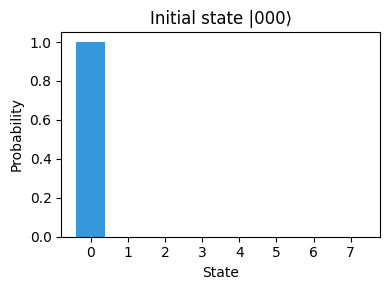

In [2]:
def initial_state(n_qubits):
    """The all-zeros state: [1, 0, 0, ...]"""
    N = 2**n_qubits
    state = np.zeros(N)
    state[0] = 1.0
    return state


def probabilities(state):
    """Born rule: probability = |amplitude|^2"""
    return np.abs(state) ** 2


def plot_state(state, target=None, title=""):
    """Bar chart of measurement probabilities."""
    probs = probabilities(state)
    N = len(probs)
    colors = ["#e74c3c" if i == target else "#3498db" for i in range(N)]

    fig, ax = plt.subplots(figsize=(max(4, N * 0.4), 3))
    ax.bar(range(N), probs, color=colors)
    ax.set_xlabel("State")
    ax.set_ylabel("Probability")
    ax.set_xticks(range(N))
    if title:
        ax.set_title(title)
    plt.tight_layout()
    plt.show()


# A 3-qubit register: 8 possible states, starting in |000⟩
state = initial_state(3)
print("Initial state vector:", state)
print("Probabilities:       ", probabilities(state))
plot_state(state, title="Initial state |000⟩")

## The Hadamard Transform

The first step spreads probability evenly across every possible state. 
The Hadamard transform does this.

For a single qubit, it's a 2×2 matrix:

$$H = \frac{1}{\sqrt{2}} \begin{bmatrix} 1 & 1 \\ 1 & -1 \end{bmatrix}$$

For n qubits, the full transform is the tensor product (Kronecker product) of n 
copies of this matrix. Applied to the all-zeros state, every amplitude becomes 
exactly $1/\sqrt{N}$ and every outcome is equally likely.

After Hadamard:
  Amplitudes: [0.3536 0.3536 0.3536 0.3536 0.3536 0.3536 0.3536 0.3536]
  Each amplitude = 1/√8 = 0.3536
  All equal? True


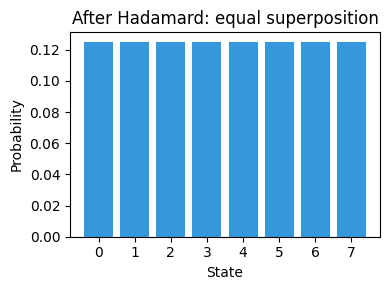

In [3]:
def hadamard(n_qubits):
    """Walsh-Hadamard matrix for n qubits, built via Kronecker product."""
    H1 = np.array([[1, 1], [1, -1]]) / sqrt(2)
    H = H1
    for _ in range(n_qubits - 1):
        H = np.kron(H, H1)
    return H


H = hadamard(3)
state = H @ initial_state(3)

print("After Hadamard:")
print("  Amplitudes:", np.round(state, 4))
print("  Each amplitude = 1/√8 =", round(1 / sqrt(8), 4))
print("  All equal?", np.allclose(state, 1 / sqrt(8)))

plot_state(state, title="After Hadamard: equal superposition")

## The Oracle: Marking the Answer

The oracle encodes the search criterion as a matrix operation. Given a target 
value $c$, it flips the sign of the amplitude at position $c$. Everything else 
stays put.

The matrix is the identity with a single $-1$ on the diagonal at position $c$. 
After applying it, probabilities haven't changed at all: squaring $-1/\sqrt{N}$ 
gives the same result as squaring $1/\sqrt{N}$. The target is tagged, but the tag 
is invisible to measurement. You can't tell by looking at the probability 
distribution that anything happened.

Amplitude of state 5:
  Before oracle: +0.3536
  After oracle:  -0.3536

Probabilities identical? True


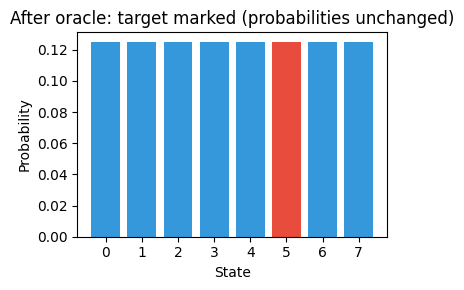

In [4]:
def oracle(n_qubits, target):
    """Flip the sign of the target state's amplitude."""
    N = 2**n_qubits
    O = np.eye(N)
    O[target, target] = -1
    return O


target = 5
state_marked = oracle(3, target) @ state

print(f"Amplitude of state {target}:")
print(f"  Before oracle: {state[target]:+.4f}")
print(f"  After oracle:  {state_marked[target]:+.4f}")
print()
print(
    f"Probabilities identical? {np.allclose(probabilities(state), probabilities(state_marked))}"
)

plot_state(
    state_marked,
    target=target,
    title="After oracle: target marked (probabilities unchanged)",
)

## Diffusion: Inversion About the Average

This step makes the invisible tag visible. The diffusion operator reflects every 
amplitude around the mean amplitude of all states.

The target's amplitude is negative (tagged by the oracle). It sits below the 
mean. Reflecting across the mean pushes it above average. Every other amplitude, 
sitting slightly above the mean, gets pushed slightly below.

The matrix:

$$D = -I + \frac{2}{N}J$$

where $I$ is the identity and $J$ is the matrix of all ones. Element by element:

$$D_{ij} = \begin{cases} -1 + \frac{2}{N} & \text{if } i = j \\ \frac{2}{N} & \text{if } i \neq j \end{cases}$$

One round of oracle followed by diffusion, and the target already stands out.

After one Grover iteration (oracle + diffusion):
  |0⟩  probability: 0.0312
  |1⟩  probability: 0.0312
  |2⟩  probability: 0.0312
  |3⟩  probability: 0.0312
  |4⟩  probability: 0.0312
  |5⟩  probability: 0.7812 ← target
  |6⟩  probability: 0.0312
  |7⟩  probability: 0.0312


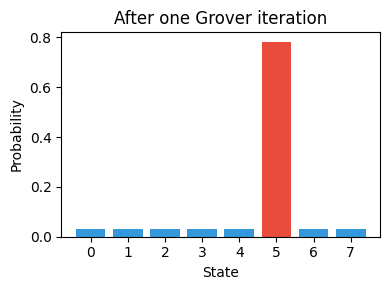

In [5]:
def diffusion(n_qubits):
    """Inversion-about-the-average matrix."""
    N = 2**n_qubits
    return -np.eye(N) + (2 / N) * np.ones((N, N))


D = diffusion(3)
state_after_one = D @ state_marked

print("After one Grover iteration (oracle + diffusion):")
for i, p in enumerate(probabilities(state_after_one)):
    marker = " ← target" if i == target else ""
    print(f"  |{i}⟩  probability: {p:.4f}{marker}")

plot_state(state_after_one, target=target, title="After one Grover iteration")

## The Complete Algorithm

Three pieces, composed:

1. Apply the Hadamard transform (equal superposition)
2. Repeat $\lfloor \frac{\pi}{4}\sqrt{N} \rfloor$ times:
   - Apply the oracle (flip the target's sign)
   - Apply diffusion (amplify the target)
3. Measure

Each iteration pushes more probability toward the target. After the optimal 
number of repetitions, the target's probability approaches 1.

Overshooting the iteration count is possible: go too far and the probability 
starts dropping back down. The optimal count, $\lfloor \frac{\pi}{4}\sqrt{N} \rfloor$, 
is where probability peaks.

Searching for 5 in a space of 8
Iterations: 2
Probability of target: 0.9453
Measured state: 5


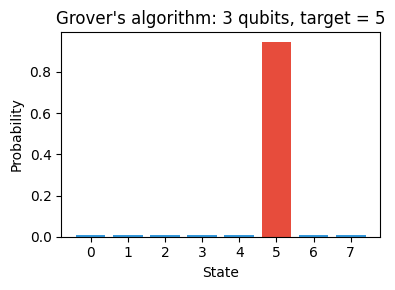

In [6]:
def grover(n_qubits, target, n_iterations=None):
    """Run Grover's algorithm. Returns the final state vector."""
    N = 2**n_qubits
    if n_iterations is None:
        n_iterations = floor(pi / 4 * sqrt(N))

    H = hadamard(n_qubits)
    O = oracle(n_qubits, target)
    D = diffusion(n_qubits)

    state = H @ initial_state(n_qubits)

    for _ in range(n_iterations):
        state = D @ (O @ state)

    return state


# 3-qubit search: find 5 among 8 values
result = grover(3, target=5)
probs = probabilities(result)

print(f"Searching for 5 in a space of 8")
print(f"Iterations: {floor(pi / 4 * sqrt(8))}")
print(f"Probability of target: {probs[5]:.4f}")
print(f"Measured state: {np.argmax(probs)}")

plot_state(result, target=5, title="Grover's algorithm: 3 qubits, target = 5")

## Scaling Up: 8 Qubits

Gross and Stallard's original paper tested Grover's algorithm on an 8-qubit 
register: 256 possible states, searching for value 243. After the optimal 
number of iterations, the target's probability dwarfed everything else.

The bar chart below should show a single red spike at state 243, with every 
other state nearly invisible.

Register size:   256 states
Target:          243
Iterations:      12
P(target):       0.999947
P(next highest): 0.000000
Measured state:  243


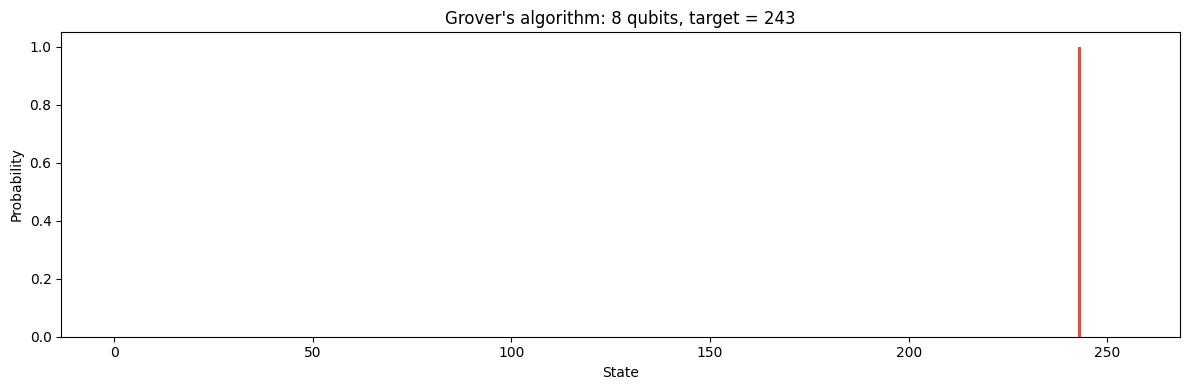

In [7]:
n_qubits = 8
target = 243
N = 2**n_qubits
optimal_iters = floor(pi / 4 * sqrt(N))

result = grover(n_qubits, target)
probs = probabilities(result)

print(f"Register size:   {N} states")
print(f"Target:          {target}")
print(f"Iterations:      {optimal_iters}")
print(f"P(target):       {probs[target]:.6f}")
print(f"P(next highest): {max(p for i, p in enumerate(probs) if i != target):.6f}")
print(f"Measured state:  {np.argmax(probs)}")

fig, ax = plt.subplots(figsize=(12, 4))
colors = ["#e74c3c" if i == target else "#3498db" for i in range(N)]
ax.bar(range(N), probs, color=colors, width=1.0)
ax.set_xlabel("State")
ax.set_ylabel("Probability")
ax.set_title(f"Grover's algorithm: 8 qubits, target = {target}")
plt.tight_layout()
plt.show()

## Watching It Converge

Probability builds with each iteration, peaks at the optimal count, then starts to 
oscillate back down. This is why the number of iterations matters: too few and the 
signal is weak, too many and you've walked past the answer.

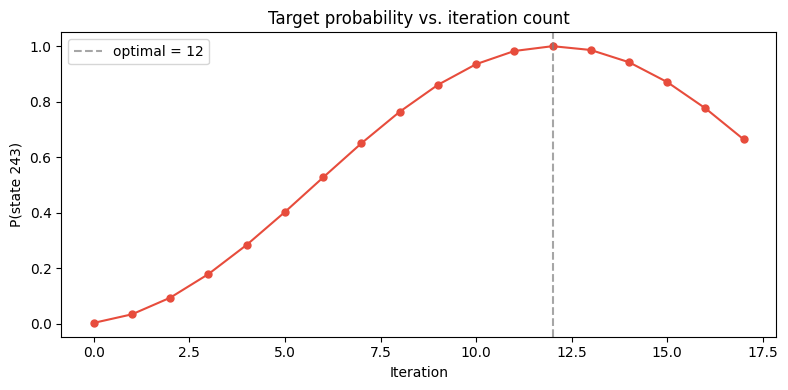

In [8]:
n_qubits = 8
target = 243
N = 2**n_qubits
max_iters = floor(pi / 4 * sqrt(N)) + 5

H = hadamard(n_qubits)
O = oracle(n_qubits, target)
D = diffusion(n_qubits)

state = H @ initial_state(n_qubits)
target_probs = [probabilities(state)[target]]

for i in range(max_iters):
    state = D @ (O @ state)
    target_probs.append(probabilities(state)[target])

optimal = floor(pi / 4 * sqrt(N))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(len(target_probs)), target_probs, "o-", color="#e74c3c", markersize=5)
ax.axvline(
    optimal, color="gray", linestyle="--", alpha=0.7, label=f"optimal = {optimal}"
)
ax.set_xlabel("Iteration")
ax.set_ylabel(f"P(state {target})")
ax.set_title("Target probability vs. iteration count")
ax.legend()
plt.tight_layout()
plt.show()

## What Just Happened

The entire algorithm is matrix multiplication. The state vector lives in a 
$2^n$-dimensional space. The Hadamard transform, the oracle, and the diffusion 
operator are all square matrices of size $2^n \times 2^n$. Running Grover's 
algorithm means multiplying the state vector by these matrices in sequence.

No quantum gates, no circuit diagrams, no bra-ket notation required. Vectors 
and matrices, the same linear algebra that shows up everywhere else. The quantum 
speedup comes from the structure of the transformations: the Hadamard creates 
interference, the oracle tags the answer with a phase flip, and diffusion exploits 
that interference to amplify the tagged state. Repeated composition of these three 
operations rotates the state vector toward the target.

The exponential size of the state space ($2^n$ dimensions for n qubits) is both 
the source of quantum computing's power and the reason classical simulation hits 
a wall. Our 8-qubit example manipulates 256×256 matrices, which is trivial. A 
30-qubit register would require matrices with over a billion entries. A real quantum 
computer handles this natively; a classical one runs out of memory. The algorithm 
is the same either way. Only the substrate changes.